# Notebook 02B - Customer Market Deep Dive

**Mục tiêu:** đào sâu riêng domain khách hàng/thị trường để kiểm tra giả thuyết vì sao doanh thu giảm mạnh sau giai đoạn 2016-2017.

**Câu hỏi trung tâm:** cú giảm này đến từ thay đổi chân dung khách hàng, giảm hiệu quả khuyến mãi, dịch vụ chưa phù hợp với tệp khách, hay do cỗ máy tăng trưởng khách hàng bị suy yếu?

**Luận điểm sẽ kiểm tra trong notebook này:**
1. Doanh thu giảm do **ít khách mua hơn**, **khách mua ít lần hơn** hay **giá trị đơn hàng giảm**?
2. Mix **demographics / acquisition / region** có thực sự thay đổi đủ mạnh để giải thích cú giảm hay không?
3. **Promo** và **service/ops quality** có xấu đi rõ rệt với khách hàng hay không?
4. Tín hiệu mạnh nhất có phải nằm ở **acquisition efficiency, retention và loyalty erosion**?

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / "datathon-2026-round-1").exists():
        PROJECT_ROOT = candidate
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

from EDA.constants.config import WEEKDAY_ORDER, AGE_ORDER
from EDA.utils.io import load_tables, build_order_metrics
from EDA.utils.plotting import (
    setup_vietnamese_style,
    save_figure,
    format_money_axis,
    format_percent_axis,
    money_formatter,
)
from EDA.utils.validation import quality_report

setup_vietnamese_style()
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

INSIGHT_LOG = []
HYPOTHESIS_SCORES = {
    "acquisition_retention_break": 0,
    "demographic_shift": 0,
    "promo_offer_mismatch": 0,
    "service_breakdown": 0,
}
HYPOTHESIS_LABELS = {
    "acquisition_retention_break": "Acquisition và retention bị gãy",
    "demographic_shift": "Chân dung khách hàng dịch chuyển mạnh",
    "promo_offer_mismatch": "Promo/offer không còn phù hợp",
    "service_breakdown": "Service/ops xuống cấp",
}

def fmt_pct(x, digits=1):
    return f"{x:.{digits}%}"

def fmt_pp(x, digits=1):
    return f"{x * 100:+.{digits}f} điểm %"

def append_insight(section, headline, evidence_lines, implication, score_updates=None):
    INSIGHT_LOG.append({
        "section": section,
        "headline": headline,
        "evidence_lines": evidence_lines,
        "implication": implication,
    })
    if score_updates:
        for key, value in score_updates.items():
            HYPOTHESIS_SCORES[key] += value

    bullet_text = "\n".join([f"- {line}" for line in evidence_lines])
    display(Markdown(
        f"**Chú thích dưới mục này - {section}:** {headline}\n\n{bullet_text}\n- Hàm ý: {implication}"
    ))

def stacked_share_chart(
    ax,
    data,
    index_col,
    segment_col,
    share_col,
    title,
    xlabel,
    ylabel="Tỷ trọng",
    segment_order=None,
    label_threshold=0.06,
):
    pivot = data.pivot(index=index_col, columns=segment_col, values=share_col).fillna(0)
    if segment_order:
        ordered = [col for col in segment_order if col in pivot.columns]
        remainder = [col for col in pivot.columns if col not in ordered]
        pivot = pivot[ordered + remainder]

    colors = sns.color_palette("tab20", n_colors=len(pivot.columns))
    bottom = np.zeros(len(pivot))
    x = np.arange(len(pivot.index))

    for color, col in zip(colors, pivot.columns):
        vals = pivot[col].to_numpy()
        bars = ax.bar(x, vals, bottom=bottom, label=col, color=color, edgecolor="white", linewidth=0.5)
        for bar, val, cur_bottom in zip(bars, vals, bottom):
            if val >= label_threshold:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    cur_bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white" if val >= 0.12 else "black",
                )
        bottom += vals

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index)
    format_percent_axis(ax)
    ax.legend(title=segment_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    return pivot

def annotate_bar_values(ax, as_percent=False, decimals=1):
    for container in ax.containers:
        labels = []
        for val in container.datavalues:
            if pd.isna(val):
                labels.append("")
            elif as_percent:
                labels.append(f"{val:.{decimals}%}")
            else:
                if decimals == 0:
                    labels.append(f"{val:,.0f}")
                else:
                    labels.append(f"{val:,.{decimals}f}")
        ax.bar_label(container, labels=labels, padding=3, fontsize=8)

## 1. Tải dữ liệu và dựng bảng fact khách hàng

In [2]:
tables = load_tables([
    "sales",
    "orders",
    "order_items",
    "customers",
    "payments",
    "shipments",
    "returns",
    "reviews",
    "web_traffic",
    "geography",
])

sales = tables["sales"].copy()
orders = tables["orders"].copy()
order_items = tables["order_items"].copy()
customers = tables["customers"].copy()
payments = tables["payments"].copy()
shipments = tables["shipments"].copy()
returns = tables["returns"].copy()
reviews = tables["reviews"].copy()
web_traffic = tables["web_traffic"].copy()
geography = tables["geography"].copy()

order_metrics = build_order_metrics(order_items)
customer_dim = customers.rename(columns={"zip": "customer_zip", "city": "customer_city"})
geo_dim = geography.rename(columns={"zip": "ship_zip", "city": "ship_city"})

order_fact = (
    orders.merge(order_metrics, on="order_id", how="left")
    .merge(customer_dim, on="customer_id", how="left")
    .merge(geo_dim, left_on="zip", right_on="ship_zip", how="left")
    .merge(payments[["order_id", "payment_value", "installments"]], on="order_id", how="left")
)
order_fact["year"] = order_fact["order_date"].dt.year
order_fact["month"] = order_fact["order_date"].dt.to_period("M").dt.to_timestamp()

sales["year"] = sales["Date"].dt.year
sales["gross_profit"] = sales["Revenue"] - sales["COGS"]
sales["gross_margin"] = sales["gross_profit"] / sales["Revenue"]

display(quality_report({
    "sales": sales,
    "orders": orders,
    "order_items": order_items,
    "customers": customers,
    "shipments": shipments,
    "returns": returns,
    "reviews": reviews,
    "web_traffic": web_traffic,
}))

append_insight(
    section="Dựng fact khách hàng",
    headline="Bộ fact đã sẵn sàng để phân rã doanh thu theo hành vi khách hàng thay vì chỉ nhìn tổng doanh thu.",
    evidence_lines=[
        f"`sales.csv` được dùng làm anchor doanh thu chính thức theo ngày/năm.",
        f"`orders + order_items` cho phép tách doanh thu theo active customers, frequency, AOV và promo ở cấp khách hàng.",
        f"Có {order_fact['customer_id'].nunique():,} khách từng mua hàng trong dữ liệu phân tích.",
    ],
    implication="Từ đây về sau, mọi insight customer market sẽ được neo vào các driver thực sự của doanh thu.",
)

,bảng,số dòng,số cột,ô thiếu,dòng trùng,dung lượng MB
3,customers,121930,7,0,0,32.7700
2,order_items,714669,7,1152816,0,80.1100
1,orders,646945,8,0,0,182.5200
5,returns,39939,7,0,0,6.6800
6,reviews,113551,7,0,0,19.4900
0,sales,3833,6,0,0,0.1600
4,shipments,566067,4,0,0,17.2800
7,web_traffic,3652,7,0,0,0.4100


**Chú thích dưới mục này - Dựng fact khách hàng:** Bộ fact đã sẵn sàng để phân rã doanh thu theo hành vi khách hàng thay vì chỉ nhìn tổng doanh thu.

- `sales.csv` được dùng làm anchor doanh thu chính thức theo ngày/năm.
- `orders + order_items` cho phép tách doanh thu theo active customers, frequency, AOV và promo ở cấp khách hàng.
- Có 90,246 khách từng mua hàng trong dữ liệu phân tích.
- Hàm ý: Từ đây về sau, mọi insight customer market sẽ được neo vào các driver thực sự của doanh thu.

## 2. Framing bài toán: doanh thu gãy sau 2016-2017 do yếu tố nào?

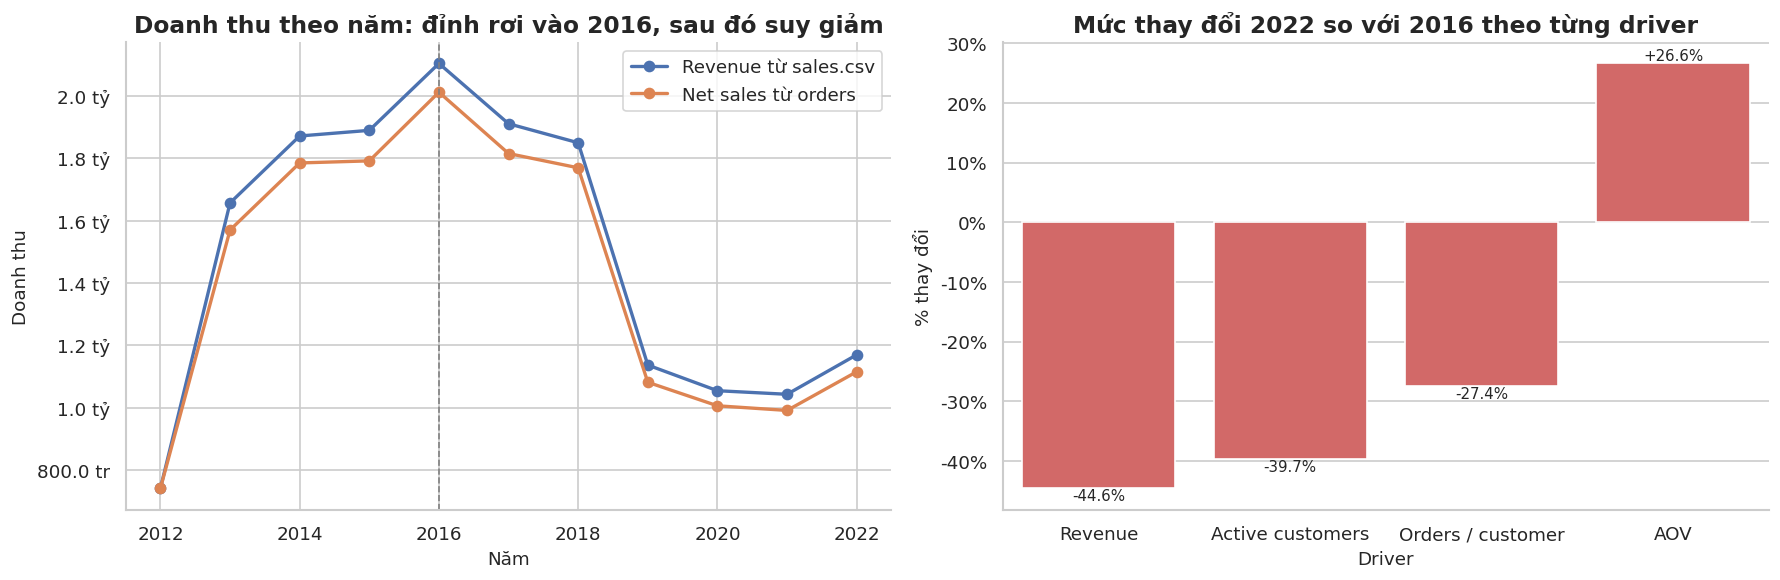

,year,Revenue,revenue_yoy,active_customers,orders_per_customer,aov,gross_margin
0,2012,"741,497,748",nan%,22068,1.45,"23,135",20.77%
1,2013,"1,657,169,417",123.49%,39384,1.95,"20,432",11.54%
2,2014,"1,871,845,883",12.95%,40376,2.00,"22,138",15.88%
3,2015,"1,889,933,827",0.97%,40807,2.02,"21,689",11.88%
4,2016,"2,104,640,678",11.36%,40933,2.01,"24,467",15.40%
5,2017,"1,911,164,325",-9.19%,39651,1.92,"23,886",11.34%
6,2018,"1,850,122,456",-3.19%,37922,1.83,"25,460",16.64%
7,2019,"1,136,801,442",-38.56%,27312,1.52,"25,999",11.58%
8,2020,"1,054,512,159",-7.24%,24335,1.43,"28,844",15.97%
9,2021,"1,043,039,820",-1.09%,23984,1.44,"28,710",9.77%


**Chú thích dưới mục này - Framing doanh thu:** Doanh thu sau đỉnh 2016 suy giảm chủ yếu vì active base và purchase frequency co lại, không phải vì AOV giảm.

- Từ 2016 đến 2022, net sales giảm -44.6%.
- Driver giảm mạnh nhất là `Revenue` (-44.6%), kế đến là `Active customers` (-39.7%).
- Driver duy nhất tăng là `AOV` (+26.6%).
- Hàm ý: Các giả thuyết phía sau cần ưu tiên giải thích vì sao ít khách mua hơn và vì sao mỗi khách mua ít lần hơn.

In [3]:
annual_sales = sales.groupby("year", as_index=False).agg(
    Revenue=("Revenue", "sum"),
    COGS=("COGS", "sum"),
    gross_profit=("gross_profit", "sum"),
)
annual_sales["gross_margin"] = annual_sales["gross_profit"] / annual_sales["Revenue"]
annual_sales["revenue_yoy"] = annual_sales["Revenue"].pct_change()

annual_customer = order_fact.groupby("year", as_index=False).agg(
    active_customers=("customer_id", "nunique"),
    orders=("order_id", "nunique"),
    net_sales=("net_sales", "sum"),
    gross_sales=("gross_sales", "sum"),
    units=("units", "sum"),
)
annual_customer["orders_per_customer"] = annual_customer["orders"] / annual_customer["active_customers"]
annual_customer["aov"] = annual_customer["net_sales"] / annual_customer["orders"]
annual_customer["revenue_per_customer"] = annual_customer["net_sales"] / annual_customer["active_customers"]

annual = annual_sales.merge(annual_customer, on="year", how="left")

peak_year = int(annual.loc[annual["Revenue"].idxmax(), "year"])
annual["revenue_index_2016"] = annual["Revenue"] / annual.loc[annual["year"] == 2016, "Revenue"].iloc[0] * 100
annual["active_customer_index_2016"] = annual["active_customers"] / annual.loc[annual["year"] == 2016, "active_customers"].iloc[0] * 100
annual["opc_index_2016"] = annual["orders_per_customer"] / annual.loc[annual["year"] == 2016, "orders_per_customer"].iloc[0] * 100
annual["aov_index_2016"] = annual["aov"] / annual.loc[annual["year"] == 2016, "aov"].iloc[0] * 100

base_2016 = annual.loc[annual["year"] == 2016].iloc[0]
latest_2022 = annual.loc[annual["year"] == 2022].iloc[0]
active_change = latest_2022["active_customers"] / base_2016["active_customers"] - 1
opc_change = latest_2022["orders_per_customer"] / base_2016["orders_per_customer"] - 1
aov_change = latest_2022["aov"] / base_2016["aov"] - 1
revenue_change = latest_2022["net_sales"] / base_2016["net_sales"] - 1

driver_compare = pd.DataFrame({
    "driver": ["Revenue", "Active customers", "Orders / customer", "AOV"],
    "2016": [
        base_2016["net_sales"],
        base_2016["active_customers"],
        base_2016["orders_per_customer"],
        base_2016["aov"],
    ],
    "2022": [
        latest_2022["net_sales"],
        latest_2022["active_customers"],
        latest_2022["orders_per_customer"],
        latest_2022["aov"],
    ],
    "pct_change": [revenue_change, active_change, opc_change, aov_change],
})
driver_compare["abs_change_rank"] = driver_compare["pct_change"].abs().rank(ascending=False, method="first")
top_falling = driver_compare.sort_values("pct_change").iloc[0]
second_falling = driver_compare.sort_values("pct_change").iloc[1]
only_growing = driver_compare.sort_values("pct_change", ascending=False).iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(annual["year"], annual["Revenue"], marker="o", linewidth=2, label="Revenue từ sales.csv")
axes[0].plot(annual["year"], annual["net_sales"], marker="o", linewidth=2, label="Net sales từ orders")
axes[0].axvline(2016, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Doanh thu theo năm: đỉnh rơi vào 2016, sau đó suy giảm")
axes[0].set_xlabel("Năm")
axes[0].set_ylabel("Doanh thu")
format_money_axis(axes[0])
axes[0].legend()

sns.barplot(data=driver_compare, x="driver", y="pct_change", color="#e45756", ax=axes[1])
axes[1].set_title("Mức thay đổi 2022 so với 2016 theo từng driver")
axes[1].set_xlabel("Driver")
axes[1].set_ylabel("% thay đổi")
format_percent_axis(axes[1])
for idx, row in driver_compare.iterrows():
    axes[1].text(idx, row["pct_change"], f"{row['pct_change']:+.1%}", ha="center", va="bottom" if row["pct_change"] >= 0 else "top", fontsize=9)
save_figure("02_customer_market_deep_revenue_bridge", fig)
plt.show()

display(annual[[
    "year", "Revenue", "revenue_yoy", "active_customers", "orders_per_customer", "aov", "gross_margin"
]].style.format({
    "Revenue": "{:,.0f}",
    "revenue_yoy": "{:.2%}",
    "orders_per_customer": "{:.2f}",
    "aov": "{:,.0f}",
    "gross_margin": "{:.2%}",
}))

append_insight(
    section="Framing doanh thu",
    headline=f"Doanh thu sau đỉnh {peak_year} suy giảm chủ yếu vì active base và purchase frequency co lại, không phải vì AOV giảm.",
    evidence_lines=[
        f"Từ 2016 đến 2022, net sales giảm {revenue_change:.1%}.",
        f"Driver giảm mạnh nhất là `{top_falling['driver']}` ({top_falling['pct_change']:+.1%}), kế đến là `{second_falling['driver']}` ({second_falling['pct_change']:+.1%}).",
        f"Driver duy nhất tăng là `{only_growing['driver']}` ({only_growing['pct_change']:+.1%}).",
    ],
    implication="Các giả thuyết phía sau cần ưu tiên giải thích vì sao ít khách mua hơn và vì sao mỗi khách mua ít lần hơn.",
    score_updates={"acquisition_retention_break": 2},
)

## 3. Kiểm tra chất lượng dữ liệu khách hàng: `signup_date` không phù hợp để làm funnel thời gian

C:\Users\ACER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


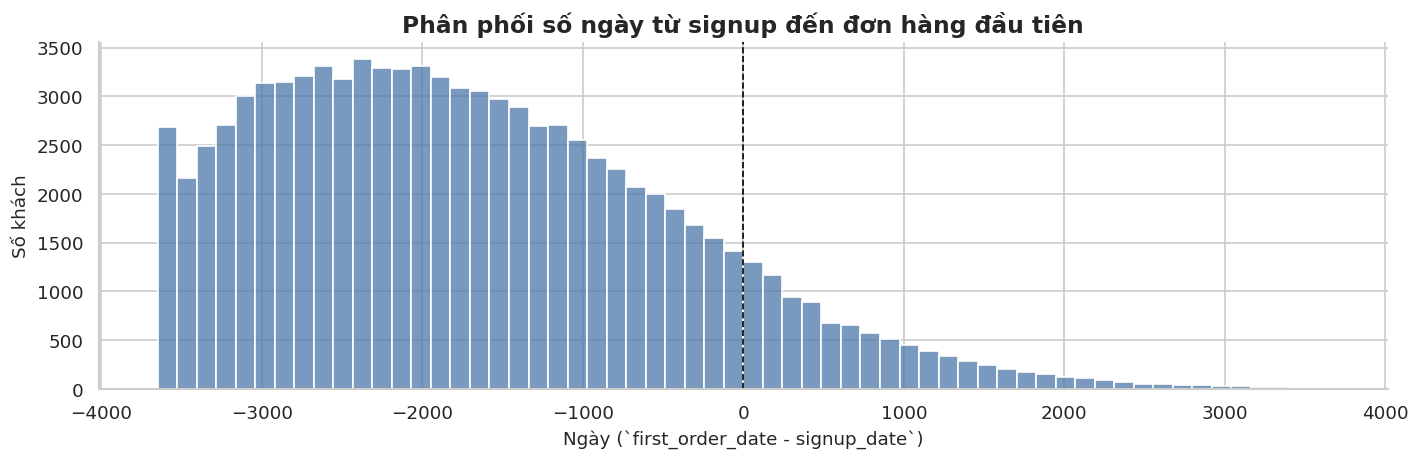

,days
count,"90,246"
mean,"-1,678"
std,"1,265"
min,"-3,832"
10%,"-3,207"
25%,"-2,676"
50%,"-1,839"
75%,-858
90%,54
max,"3,725"


**Chú thích dưới mục này - Chất lượng dữ liệu khách hàng:** `signup_date` không đủ tin cậy để làm acquisition funnel theo thời gian.

- Có 66.1% khách có `first_order_date < signup_date`.
- Trung vị `first_order_date - signup_date` là -1,839 ngày, cho thấy mốc signup bị lệch đáng kể.
- Hàm ý: Cohort khách mới trong notebook này được neo theo năm phát sinh đơn hàng đầu tiên thay vì theo `signup_date`.

In [4]:
first_order = order_fact.groupby("customer_id", as_index=False).agg(first_order_date=("order_date", "min"))
first_order["first_order_year"] = first_order["first_order_date"].dt.year

customer_quality = customers.merge(first_order, on="customer_id", how="left")
customer_quality["days_signup_to_first_order"] = (
    customer_quality["first_order_date"] - customer_quality["signup_date"]
).dt.days

negative_signup_share = (customer_quality["days_signup_to_first_order"] < 0).mean()
valid_lag = customer_quality["days_signup_to_first_order"].dropna()

fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(valid_lag.clip(lower=-3650, upper=3650), bins=60, color="#4c78a8", ax=ax)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Phân phối số ngày từ signup đến đơn hàng đầu tiên")
ax.set_xlabel("Ngày (`first_order_date - signup_date`)")
ax.set_ylabel("Số khách")
save_figure("02_customer_market_deep_signup_quality", fig)
plt.show()

lag_summary = valid_lag.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame("days")
display(lag_summary.style.format("{:,.0f}"))

append_insight(
    section="Chất lượng dữ liệu khách hàng",
    headline="`signup_date` không đủ tin cậy để làm acquisition funnel theo thời gian.",
    evidence_lines=[
        f"Có {negative_signup_share:.1%} khách có `first_order_date < signup_date`.",
        f"Trung vị `first_order_date - signup_date` là {valid_lag.median():,.0f} ngày, cho thấy mốc signup bị lệch đáng kể.",
    ],
    implication="Cohort khách mới trong notebook này được neo theo năm phát sinh đơn hàng đầu tiên thay vì theo `signup_date`.",
)

## 4. Acquisition và retention: cỗ máy khách hàng suy yếu ở cả đầu vào lẫn đầu ra

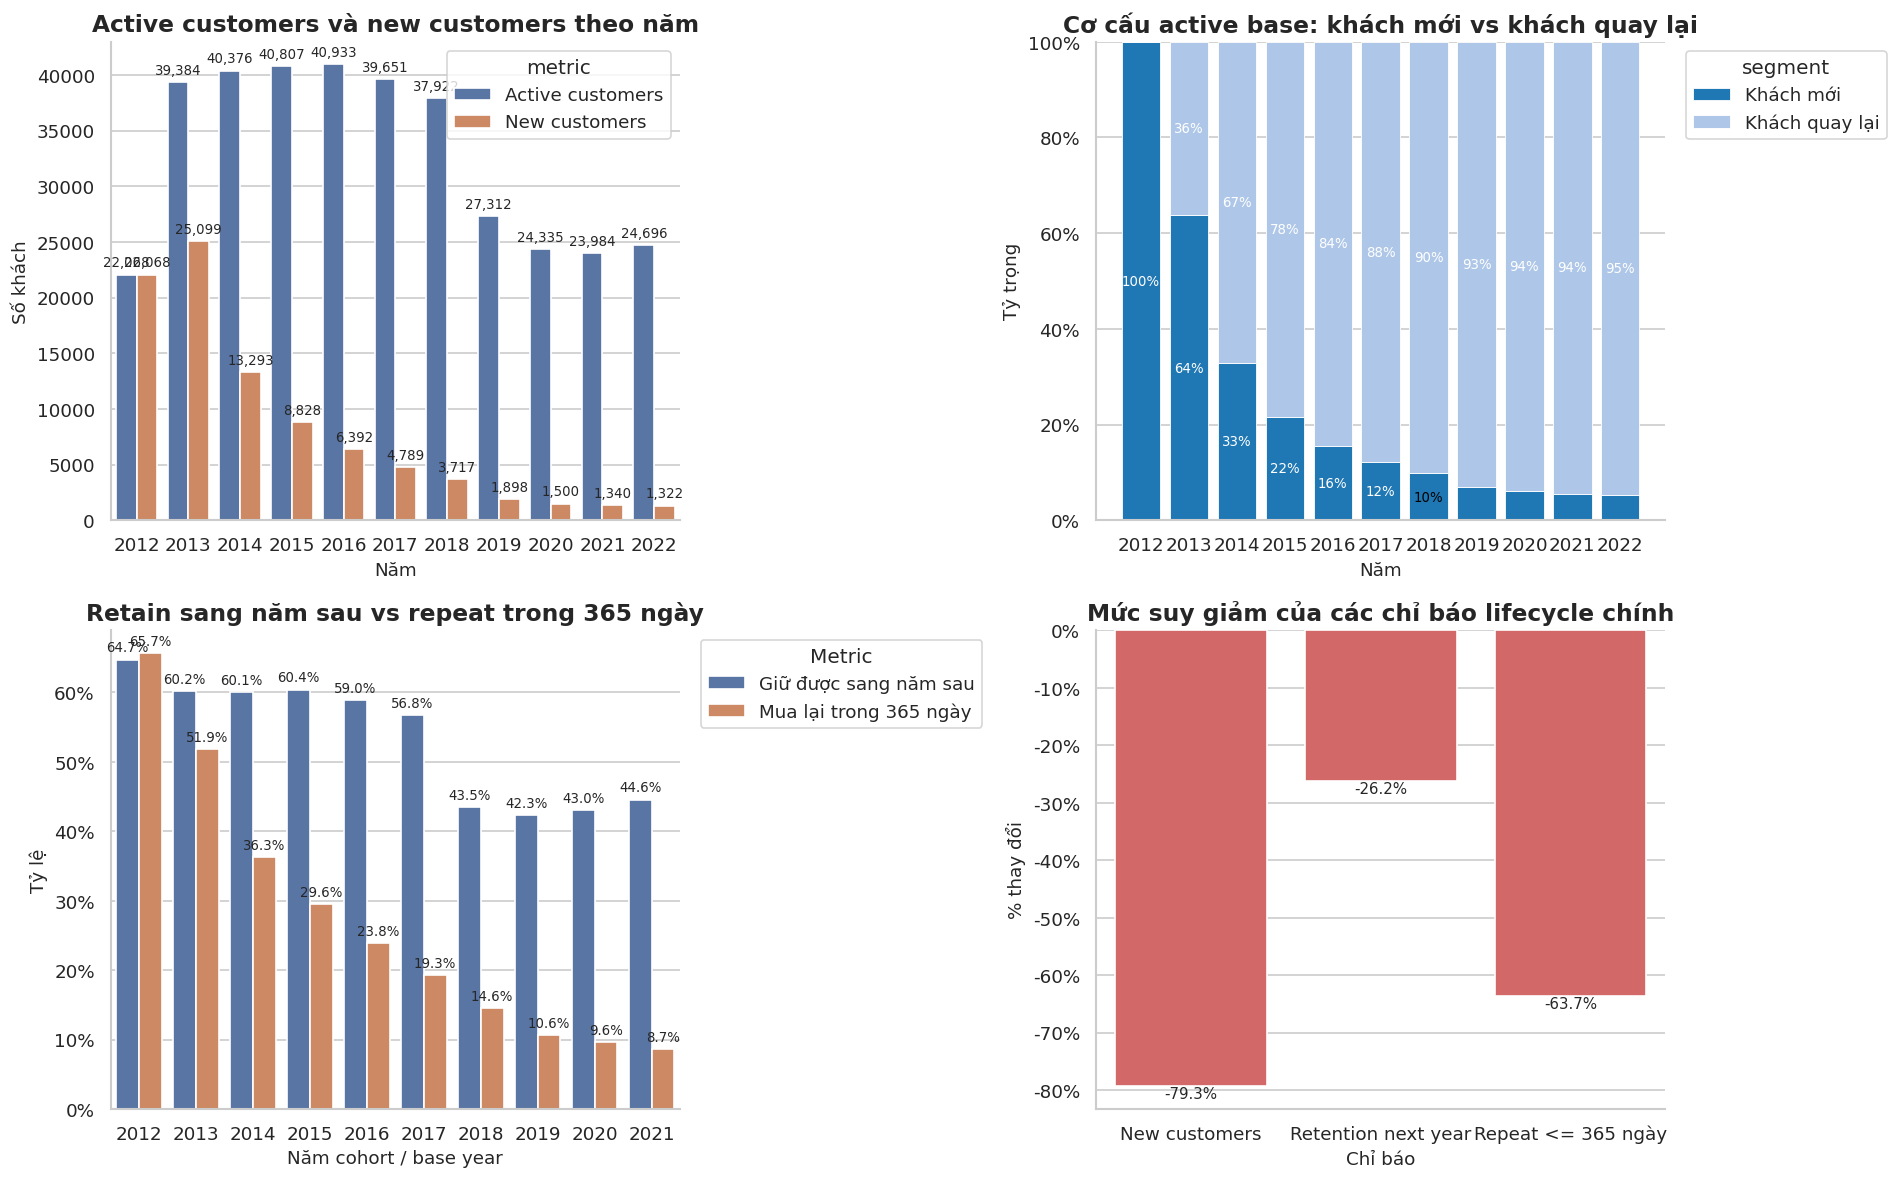

,year,active_customers,orders,net_sales,new_customers,returning_customers,new_customer_share
0,2012,22068,32051,"741,497,748",22068,0,100.00%
1,2013,39384,76849,"1,570,165,169",25099,14285,63.73%
2,2014,40376,80645,"1,785,342,715",13293,27083,32.92%
3,2015,40807,82622,"1,792,009,967",8828,31979,21.63%
4,2016,40933,82247,"2,012,364,466",6392,34541,15.62%
5,2017,39651,76010,"1,815,546,634",4789,34862,12.08%
6,2018,37922,69510,"1,769,723,180",3717,34205,9.80%
7,2019,27312,41601,"1,081,589,581",1898,25414,6.95%
8,2020,24335,34881,"1,006,108,536",1500,22835,6.16%
9,2021,23984,34525,"991,214,174",1340,22644,5.59%


,base_year,customers,retained_next_year,retention_next_year
0,2012,22068,14285,64.73%
1,2013,39384,23727,60.25%
2,2014,40376,24255,60.07%
3,2015,40807,24646,60.40%
4,2016,40933,24131,58.95%
5,2017,39651,22504,56.76%
6,2018,37922,16488,43.48%
7,2019,27312,11562,42.33%
8,2020,24335,10471,43.03%
9,2021,23984,10687,44.56%


,first_order_year,new_customers,repeat_365,repeat_rate_365
0,2012,22068,14488,65.65%
1,2013,25099,13017,51.86%
2,2014,13293,4826,36.30%
3,2015,8828,2610,29.57%
4,2016,6392,1524,23.84%
5,2017,4789,926,19.34%
6,2018,3717,541,14.55%
7,2019,1898,201,10.59%
8,2020,1500,144,9.60%
9,2021,1340,116,8.66%


**Chú thích dưới mục này - Acquisition & retention:** Cú giảm doanh thu gắn với sự gãy đồng thời của máy hút khách mới và khả năng giữ khách.

- New customers giảm từ 6,392 xuống 1,322 (-79.3%).
- Retention sang năm sau giảm từ 59.0% (base 2016) xuống 43.5% (base 2018).
- Repeat rate trong 365 ngày của cohort khách mới giảm từ 23.8% xuống 8.7%.
- Hàm ý: Nếu không sửa được cả acquisition efficiency lẫn retention sớm sau đơn đầu, doanh thu rất khó quay lại mức trước 2017.

In [5]:
annual_active = order_fact.groupby("year", as_index=False).agg(
    active_customers=("customer_id", "nunique"),
    orders=("order_id", "nunique"),
    net_sales=("net_sales", "sum"),
)

annual_new = first_order.groupby("first_order_year", as_index=False).agg(
    new_customers=("customer_id", "nunique")
).rename(columns={"first_order_year": "year"})
annual_flow = annual_active.merge(annual_new, on="year", how="left")
annual_flow["returning_customers"] = annual_flow["active_customers"] - annual_flow["new_customers"]
annual_flow["new_customer_share"] = annual_flow["new_customers"] / annual_flow["active_customers"]

active_pairs = order_fact[["customer_id", "year"]].drop_duplicates()
retention_rows = []
years = sorted(active_pairs["year"].unique())
for year in years[:-1]:
    base_customers = set(active_pairs.loc[active_pairs["year"] == year, "customer_id"])
    next_customers = set(active_pairs.loc[active_pairs["year"] == year + 1, "customer_id"])
    retained = len(base_customers & next_customers)
    retention_rows.append({
        "base_year": year,
        "customers": len(base_customers),
        "retained_next_year": retained,
        "retention_next_year": retained / len(base_customers),
    })
annual_retention = pd.DataFrame(retention_rows)

second_order = (
    order_fact.sort_values(["customer_id", "order_date"])
    .groupby("customer_id")
    .nth(1)
    .reset_index()[["customer_id", "order_date"]]
    .rename(columns={"order_date": "second_order_date"})
)
cohort_repeat = first_order.merge(second_order, on="customer_id", how="left")
cohort_repeat["repeat_within_365"] = (
    (cohort_repeat["second_order_date"] - cohort_repeat["first_order_date"]).dt.days <= 365
).fillna(False)
repeat_365 = (
    cohort_repeat[cohort_repeat["first_order_year"] <= 2021]
    .groupby("first_order_year", as_index=False)
    .agg(
        new_customers=("customer_id", "nunique"),
        repeat_365=("repeat_within_365", "sum"),
    )
)
repeat_365["repeat_rate_365"] = repeat_365["repeat_365"] / repeat_365["new_customers"]

lifecycle_share = annual_flow[["year", "new_customer_share"]].copy()
lifecycle_share["returning_customer_share"] = 1 - lifecycle_share["new_customer_share"]
lifecycle_share = lifecycle_share.melt(
    id_vars="year",
    value_vars=["new_customer_share", "returning_customer_share"],
    var_name="segment",
    value_name="share",
)
lifecycle_share["segment"] = lifecycle_share["segment"].map({
    "new_customer_share": "Khách mới",
    "returning_customer_share": "Khách quay lại",
})

retention_plot = annual_retention.melt(
    id_vars="base_year",
    value_vars=["retention_next_year"],
    var_name="metric",
    value_name="rate",
)
repeat_plot = repeat_365.rename(columns={"first_order_year": "base_year"}).melt(
    id_vars="base_year",
    value_vars=["repeat_rate_365"],
    var_name="metric",
    value_name="rate",
)
retention_compare = pd.concat([
    retention_plot.assign(metric_label="Giữ được sang năm sau"),
    repeat_plot.assign(metric_label="Mua lại trong 365 ngày"),
], ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
flow_plot = annual_flow.melt(
    id_vars="year",
    value_vars=["active_customers", "new_customers"],
    var_name="metric",
    value_name="customers",
)
flow_plot["metric"] = flow_plot["metric"].map({
    "active_customers": "Active customers",
    "new_customers": "New customers",
})
sns.barplot(data=flow_plot, x="year", y="customers", hue="metric", ax=axes[0, 0])
axes[0, 0].set_title("Active customers và new customers theo năm")
axes[0, 0].set_xlabel("Năm")
axes[0, 0].set_ylabel("Số khách")
annotate_bar_values(axes[0, 0], as_percent=False, decimals=0)

stacked_share_chart(
    axes[0, 1],
    lifecycle_share,
    index_col="year",
    segment_col="segment",
    share_col="share",
    title="Cơ cấu active base: khách mới vs khách quay lại",
    xlabel="Năm",
    segment_order=["Khách mới", "Khách quay lại"],
    label_threshold=0.08,
)

sns.barplot(data=retention_compare, x="base_year", y="rate", hue="metric_label", ax=axes[1, 0])
axes[1, 0].set_title("Retain sang năm sau vs repeat trong 365 ngày")
axes[1, 0].set_xlabel("Năm cohort / base year")
axes[1, 0].set_ylabel("Tỷ lệ")
format_percent_axis(axes[1, 0])
annotate_bar_values(axes[1, 0], as_percent=True)
axes[1, 0].legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")

new_2016 = annual_flow.loc[annual_flow["year"] == 2016, "new_customers"].iloc[0]
new_2022 = annual_flow.loc[annual_flow["year"] == 2022, "new_customers"].iloc[0]
ret_2016 = annual_retention.loc[annual_retention["base_year"] == 2016, "retention_next_year"].iloc[0]
ret_2018 = annual_retention.loc[annual_retention["base_year"] == 2018, "retention_next_year"].iloc[0]
repeat_2016 = repeat_365.loc[repeat_365["first_order_year"] == 2016, "repeat_rate_365"].iloc[0]
repeat_2021 = repeat_365.loc[repeat_365["first_order_year"] == 2021, "repeat_rate_365"].iloc[0]

decline_metrics = pd.DataFrame({
    "metric": ["New customers", "Retention next year", "Repeat <= 365 ngày"],
    "from_value": [new_2016, ret_2016, repeat_2016],
    "to_value": [new_2022, ret_2018, repeat_2021],
    "change_pct": [new_2022 / new_2016 - 1, ret_2018 / ret_2016 - 1, repeat_2021 / repeat_2016 - 1],
})
sns.barplot(data=decline_metrics, x="metric", y="change_pct", color="#e45756", ax=axes[1, 1])
axes[1, 1].set_title("Mức suy giảm của các chỉ báo lifecycle chính")
axes[1, 1].set_xlabel("Chỉ báo")
axes[1, 1].set_ylabel("% thay đổi")
format_percent_axis(axes[1, 1])
for idx, row in decline_metrics.iterrows():
    axes[1, 1].text(idx, row["change_pct"], f"{row['change_pct']:+.1%}", ha="center", va="bottom" if row["change_pct"] >= 0 else "top", fontsize=9)
save_figure("02_customer_market_deep_lifecycle", fig)
plt.show()

display(annual_flow.style.format({"new_customer_share": "{:.2%}", "net_sales": "{:,.0f}"}))
display(annual_retention.style.format({"retention_next_year": "{:.2%}"}))
display(repeat_365.style.format({"repeat_rate_365": "{:.2%}"}))

append_insight(
    section="Acquisition & retention",
    headline="Cú giảm doanh thu gắn với sự gãy đồng thời của máy hút khách mới và khả năng giữ khách.",
    evidence_lines=[
        f"New customers giảm từ {new_2016:,} xuống {new_2022:,} ({new_2022 / new_2016 - 1:+.1%}).",
        f"Retention sang năm sau giảm từ {ret_2016:.1%} (base 2016) xuống {ret_2018:.1%} (base 2018).",
        f"Repeat rate trong 365 ngày của cohort khách mới giảm từ {repeat_2016:.1%} xuống {repeat_2021:.1%}.",
    ],
    implication="Nếu không sửa được cả acquisition efficiency lẫn retention sớm sau đơn đầu, doanh thu rất khó quay lại mức trước 2017.",
    score_updates={"acquisition_retention_break": 4},
)

## 5. Loyalty erosion: tệp khách mua nhiều lần bị co rút mạnh

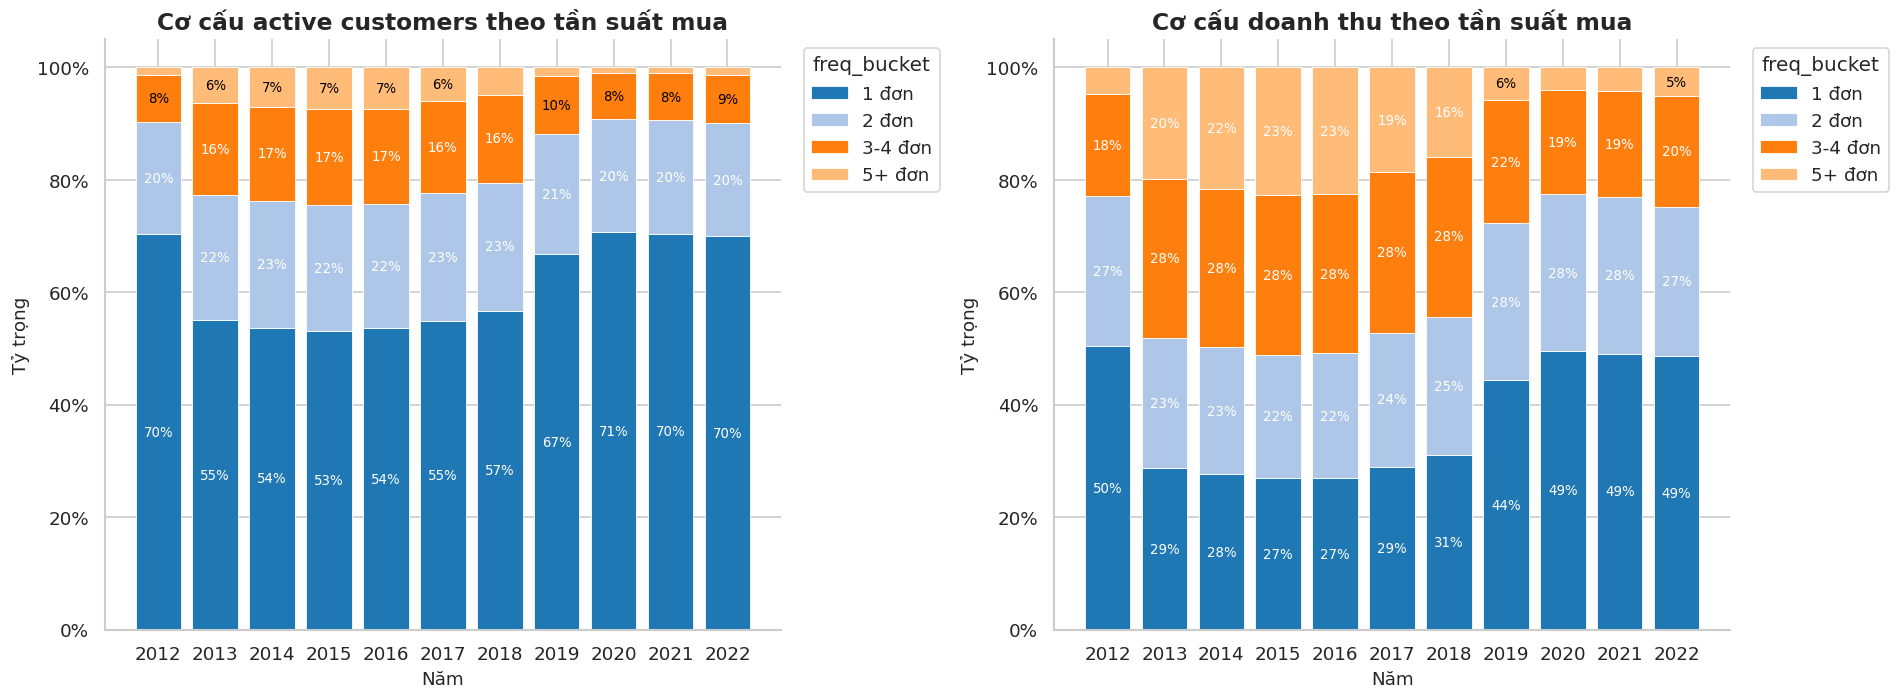

freq_bucket,1 đơn,2 đơn,3-4 đơn,5+ đơn
year,,,,
2012,70.28%,20.02%,8.34%,1.36%
2013,55.00%,22.27%,16.31%,6.42%
2014,53.70%,22.59%,16.74%,6.97%
2015,53.17%,22.31%,17.16%,7.36%
2016,53.57%,22.12%,16.93%,7.38%
2017,54.84%,22.80%,16.43%,5.94%
2018,56.71%,22.78%,15.64%,4.87%
2019,66.74%,21.33%,10.33%,1.60%
2020,70.70%,20.03%,8.23%,1.04%


freq_bucket,1 đơn,2 đơn,3-4 đơn,5+ đơn
year,,,,
2012,50.42%,26.65%,18.12%,4.81%
2013,28.70%,23.19%,28.23%,19.89%
2014,27.60%,22.57%,28.14%,21.69%
2015,26.91%,21.92%,28.46%,22.71%
2016,26.86%,22.28%,28.25%,22.61%
2017,28.98%,23.83%,28.49%,18.70%
2018,31.02%,24.64%,28.42%,15.91%
2019,44.35%,27.89%,21.93%,5.83%
2020,49.46%,27.97%,18.58%,3.99%


**Chú thích dưới mục này - Loyalty erosion:** Tệp khách trung thành co lại mạnh, còn tệp mua một lần ngày càng chiếm tỷ trọng lớn hơn.

- Nhóm `5+ đơn` giảm từ 7.38% xuống 1.30% trong active base (-6.1 điểm %).
- Doanh thu đến từ nhóm `5+ đơn` giảm từ 22.61% xuống 5.17% (-17.4 điểm %).
- Ngược lại, tỷ trọng khách `1 đơn` tăng thêm +16.4 điểm % so với 2016.
- Hàm ý: Doanh nghiệp đang mất dần tầng khách tạo doanh thu cấu trúc; đây là dấu hiệu loyalty erosion chứ không chỉ là hụt khách tạm thời.

In [6]:
customer_year = order_fact.groupby(["year", "customer_id"], as_index=False).agg(
    orders=("order_id", "nunique"),
    net_sales=("net_sales", "sum"),
)

def bucket(order_count: int) -> str:
    if order_count == 1:
        return "1 đơn"
    if order_count == 2:
        return "2 đơn"
    if order_count <= 4:
        return "3-4 đơn"
    return "5+ đơn"

customer_year["freq_bucket"] = customer_year["orders"].map(bucket)
frequency = customer_year.groupby(["year", "freq_bucket"], as_index=False).agg(
    customers=("customer_id", "nunique"),
    net_sales=("net_sales", "sum"),
)
frequency["customer_share"] = frequency.groupby("year")["customers"].transform(lambda s: s / s.sum())
frequency["sales_share"] = frequency.groupby("year")["net_sales"].transform(lambda s: s / s.sum())

bucket_order = ["1 đơn", "2 đơn", "3-4 đơn", "5+ đơn"]
frequency["freq_bucket"] = pd.Categorical(frequency["freq_bucket"], categories=bucket_order, ordered=True)
frequency = frequency.sort_values(["year", "freq_bucket"])

loyal = frequency[frequency["freq_bucket"] == "5+ đơn"].copy()
base_2016 = loyal.loc[loyal["year"] == 2016].iloc[0]
latest_2022 = loyal.loc[loyal["year"] == 2022].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
stacked_share_chart(
    axes[0],
    frequency,
    index_col="year",
    segment_col="freq_bucket",
    share_col="customer_share",
    title="Cơ cấu active customers theo tần suất mua",
    xlabel="Năm",
    segment_order=bucket_order,
    label_threshold=0.05,
)

stacked_share_chart(
    axes[1],
    frequency,
    index_col="year",
    segment_col="freq_bucket",
    share_col="sales_share",
    title="Cơ cấu doanh thu theo tần suất mua",
    xlabel="Năm",
    segment_order=bucket_order,
    label_threshold=0.05,
)
save_figure("02_customer_market_deep_loyalty", fig)
plt.show()

loyal_customer_change = latest_2022["customer_share"] - base_2016["customer_share"]
loyal_sales_change = latest_2022["sales_share"] - base_2016["sales_share"]
single_order = frequency[frequency["freq_bucket"] == "1 đơn"].set_index("year")
single_order_growth = single_order.loc[2022, "customer_share"] - single_order.loc[2016, "customer_share"]

display(frequency.pivot(index="year", columns="freq_bucket", values="customer_share").style.format("{:.2%}"))
display(frequency.pivot(index="year", columns="freq_bucket", values="sales_share").style.format("{:.2%}"))

append_insight(
    section="Loyalty erosion",
    headline="Tệp khách trung thành co lại mạnh, còn tệp mua một lần ngày càng chiếm tỷ trọng lớn hơn.",
    evidence_lines=[
        f"Nhóm `5+ đơn` giảm từ {base_2016['customer_share']:.2%} xuống {latest_2022['customer_share']:.2%} trong active base ({fmt_pp(loyal_customer_change)}).",
        f"Doanh thu đến từ nhóm `5+ đơn` giảm từ {base_2016['sales_share']:.2%} xuống {latest_2022['sales_share']:.2%} ({fmt_pp(loyal_sales_change)}).",
        f"Ngược lại, tỷ trọng khách `1 đơn` tăng thêm {fmt_pp(single_order_growth)} so với 2016.",
    ],
    implication="Doanh nghiệp đang mất dần tầng khách tạo doanh thu cấu trúc; đây là dấu hiệu loyalty erosion chứ không chỉ là hụt khách tạm thời.",
    score_updates={"acquisition_retention_break": 3},
)

## 6. Demographics và market mix: cấu trúc khách gần như ổn định, nhưng quy mô co lại trên mọi nhóm

C:\Users\ACER\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


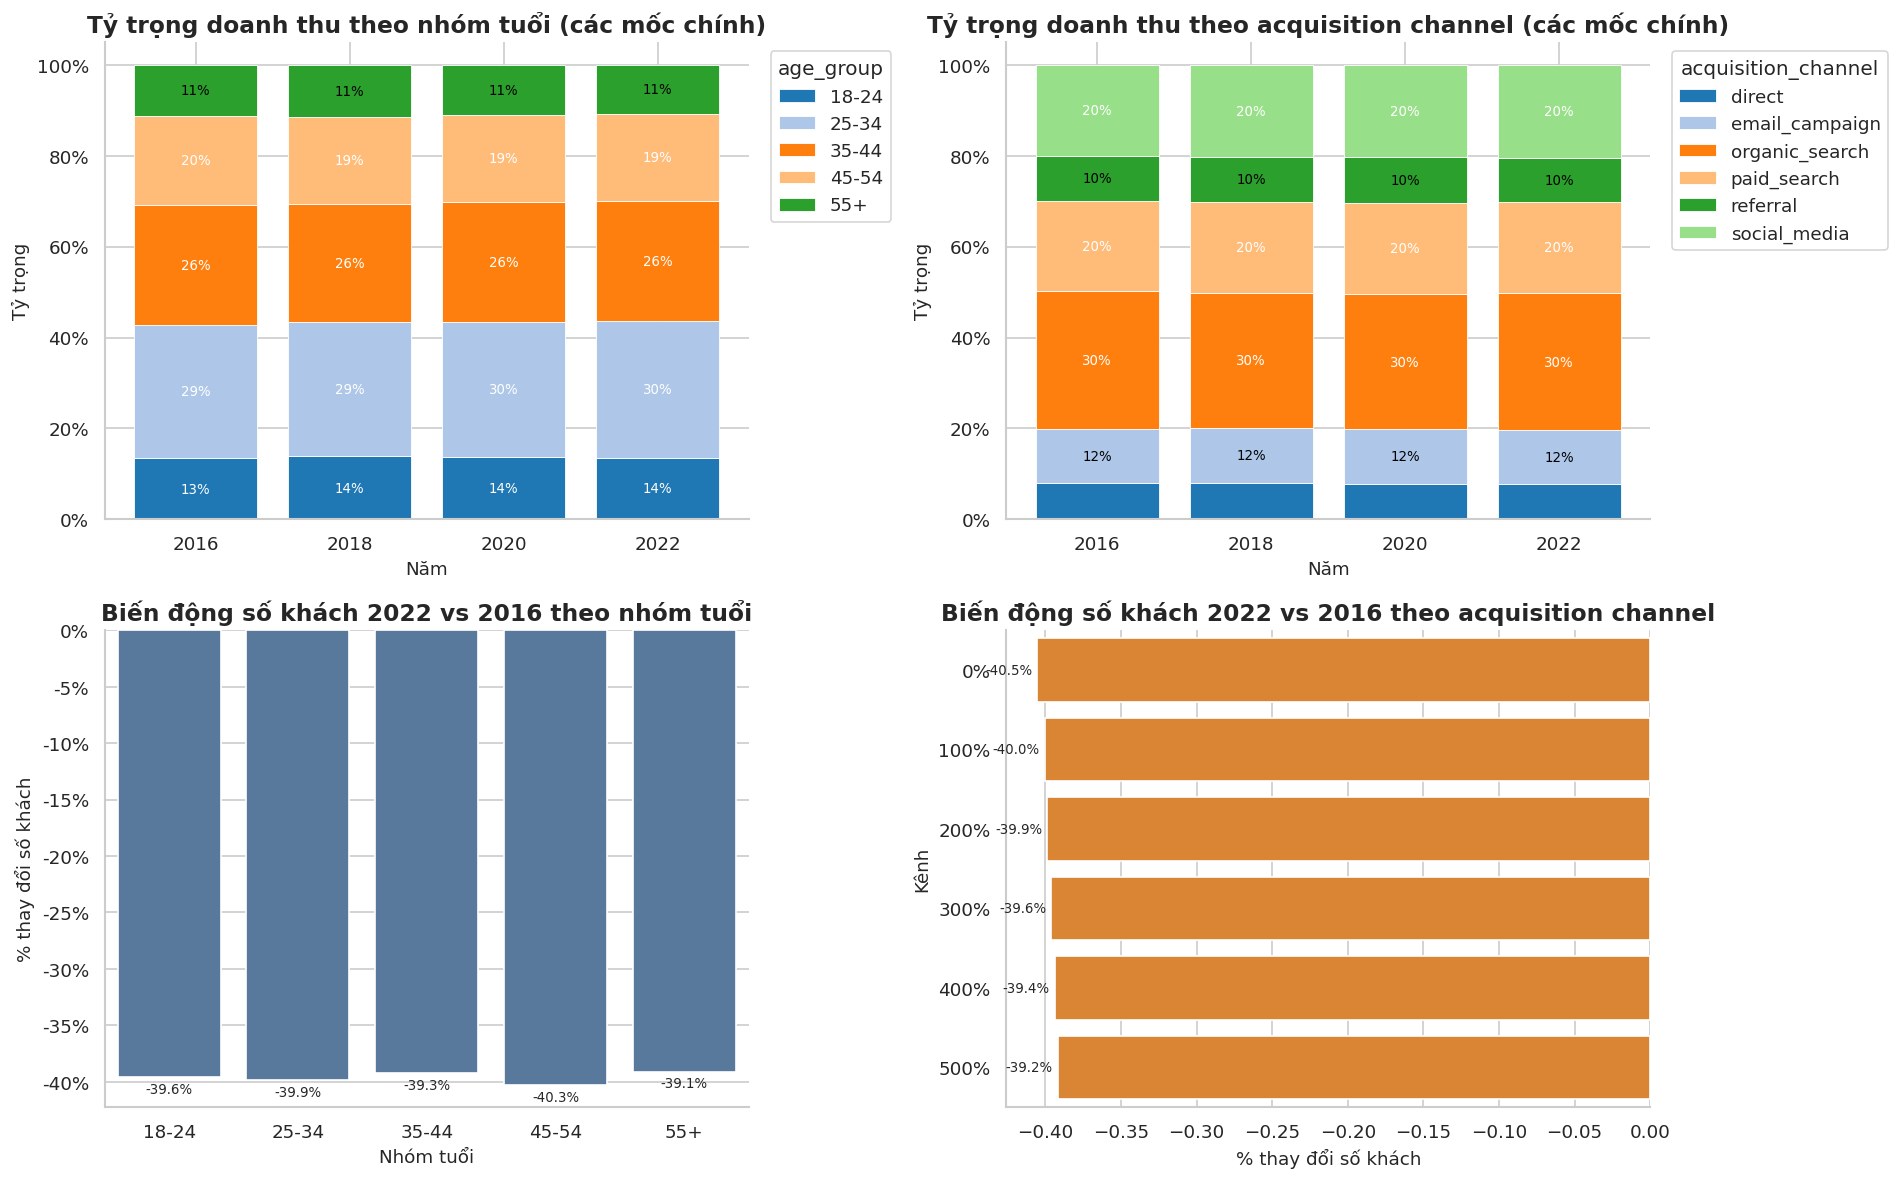

C:\Users\ACER\AppData\Local\Temp\ipykernel_28248\2114625301.py:96: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("age_group")


,year,age_group,customers,orders_per_customer,rev_per_customer,sales_share
20,2016,18-24,5643,1.99,"47,925",13.44%
21,2016,25-34,12119,1.99,"48,861",29.43%
22,2016,35-44,10733,2.02,"49,241",26.26%
23,2016,45-54,7926,2.02,"49,821",19.62%
24,2016,55+,4512,2.05,"50,175",11.25%
50,2022,18-24,3408,1.43,"44,199",13.51%
51,2022,25-34,7286,1.48,"46,079",30.10%
52,2022,35-44,6519,1.46,"45,212",26.43%
53,2022,45-54,4735,1.45,"44,990",19.10%
54,2022,55+,2748,1.44,"44,099",10.87%


,year,acquisition_channel,customers,orders_per_customer,rev_per_customer,sales_share
24,2016,direct,3349,1.98,"47,818",7.96%
25,2016,email_campaign,4910,2.01,"49,164",12.00%
26,2016,organic_search,12246,2.02,"49,648",30.21%
27,2016,paid_search,8192,2.00,"48,889",19.90%
28,2016,referral,4075,2.01,"48,601",9.84%
29,2016,social_media,8161,2.02,"49,539",20.09%
60,2022,direct,1991,1.47,"43,818",7.82%
61,2022,email_campaign,2977,1.45,"43,955",11.73%
62,2022,organic_search,7394,1.45,"45,485",30.15%
63,2022,paid_search,4926,1.47,"45,660",20.17%


,year,region,customers,orders_per_customer,rev_per_customer,sales_share
12,2016,Central,12409,1.82,"46,693",28.79%
13,2016,East,20336,1.83,"45,625",46.11%
14,2016,West,8188,2.75,"61,691",25.10%
30,2022,Central,7821,1.43,"46,618",32.69%
31,2022,East,11891,1.39,"43,799",46.70%
32,2022,West,4984,1.66,"46,126",20.61%


**Chú thích dưới mục này - Demographics & market mix:** Mix khách hàng khá ổn định; vấn đề chính là quy mô co lại trên diện rộng chứ không phải dịch chuyển mạnh sang một chân dung mới.

- Biến động sales share lớn nhất giữa 2016-2022 ở nhóm tuổi chỉ khoảng 0.74 điểm %.
- Biến động sales share lớn nhất giữa 2016-2022 ở acquisition channel chỉ khoảng 0.67 điểm %.
- Nhóm tuổi giảm số khách mạnh nhất là `45-54` (-40.3%); kênh giảm mạnh nhất là `direct` (-40.5%).
- Hàm ý: Không nên đổ toàn bộ nguyên nhân cho việc “khách đổi tệp”; trọng tâm đúng hơn là repair acquisition, retention và loyalty across segments.

In [7]:
def segment_yearly_metrics(column: str) -> pd.DataFrame:
    frame = (
        order_fact.groupby(["year", column], as_index=False)
        .agg(
            customers=("customer_id", "nunique"),
            orders=("order_id", "nunique"),
            net_sales=("net_sales", "sum"),
        )
    )
    frame["sales_share"] = frame.groupby("year")["net_sales"].transform(lambda s: s / s.sum())
    frame["customer_share"] = frame.groupby("year")["customers"].transform(lambda s: s / s.sum())
    frame["orders_per_customer"] = frame["orders"] / frame["customers"]
    frame["rev_per_customer"] = frame["net_sales"] / frame["customers"]
    return frame

age_metrics = segment_yearly_metrics("age_group")
age_metrics["age_group"] = pd.Categorical(age_metrics["age_group"], categories=AGE_ORDER, ordered=True)
age_metrics = age_metrics.sort_values(["year", "age_group"])

channel_metrics = segment_yearly_metrics("acquisition_channel")
region_metrics = segment_yearly_metrics("region")
gender_metrics = segment_yearly_metrics("gender")

age_compare = (
    age_metrics[age_metrics["year"].isin([2016, 2022])]
    .pivot(index="age_group", columns="year", values="customers")
    .rename(columns={2016: "customers_2016", 2022: "customers_2022"})
)
age_compare["customer_change_pct"] = age_compare["customers_2022"] / age_compare["customers_2016"] - 1

channel_compare = (
    channel_metrics[channel_metrics["year"].isin([2016, 2022])]
    .pivot(index="acquisition_channel", columns="year", values="customers")
    .rename(columns={2016: "customers_2016", 2022: "customers_2022"})
)
channel_compare["customer_change_pct"] = channel_compare["customers_2022"] / channel_compare["customers_2016"] - 1

snapshot_years = [2016, 2018, 2020, 2022]
age_share_snapshots = age_metrics[age_metrics["year"].isin(snapshot_years)].copy()
channel_share_snapshots = channel_metrics[channel_metrics["year"].isin(snapshot_years)].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
stacked_share_chart(
    axes[0, 0],
    age_share_snapshots,
    index_col="year",
    segment_col="age_group",
    share_col="sales_share",
    title="Tỷ trọng doanh thu theo nhóm tuổi (các mốc chính)",
    xlabel="Năm",
    segment_order=AGE_ORDER,
    label_threshold=0.08,
)

stacked_share_chart(
    axes[0, 1],
    channel_share_snapshots,
    index_col="year",
    segment_col="acquisition_channel",
    share_col="sales_share",
    title="Tỷ trọng doanh thu theo acquisition channel (các mốc chính)",
    xlabel="Năm",
    label_threshold=0.09,
)

sns.barplot(
    data=age_compare.reset_index(),
    x="age_group",
    y="customer_change_pct",
    color="#4c78a8",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Biến động số khách 2022 vs 2016 theo nhóm tuổi")
axes[1, 0].set_xlabel("Nhóm tuổi")
axes[1, 0].set_ylabel("% thay đổi số khách")
format_percent_axis(axes[1, 0])
annotate_bar_values(axes[1, 0], as_percent=True)

sns.barplot(
    data=channel_compare.reset_index().sort_values("customer_change_pct"),
    y="acquisition_channel",
    x="customer_change_pct",
    color="#f58518",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Biến động số khách 2022 vs 2016 theo acquisition channel")
axes[1, 1].set_xlabel("% thay đổi số khách")
axes[1, 1].set_ylabel("Kênh")
format_percent_axis(axes[1, 1])
annotate_bar_values(axes[1, 1], as_percent=True)
save_figure("02_customer_market_deep_mix_stability", fig)
plt.show()

share_range_age = (
    age_metrics[age_metrics["year"].between(2016, 2022)]
    .groupby("age_group")
    .agg(min_share=("sales_share", "min"), max_share=("sales_share", "max"))
)
share_range_age["range_pp"] = (share_range_age["max_share"] - share_range_age["min_share"]) * 100
share_range_channel = (
    channel_metrics[channel_metrics["year"].between(2016, 2022)]
    .groupby("acquisition_channel")
    .agg(min_share=("sales_share", "min"), max_share=("sales_share", "max"))
)
share_range_channel["range_pp"] = (share_range_channel["max_share"] - share_range_channel["min_share"]) * 100
max_age_share_shift = share_range_age["range_pp"].max()
max_channel_share_shift = share_range_channel["range_pp"].max()
worst_age_decline = age_compare["customer_change_pct"].idxmin()
worst_channel_decline = channel_compare["customer_change_pct"].idxmin()

display(age_metrics[age_metrics["year"].isin([2016, 2022])][[
    "year", "age_group", "customers", "orders_per_customer", "rev_per_customer", "sales_share"
]].style.format({
    "orders_per_customer": "{:.2f}",
    "rev_per_customer": "{:,.0f}",
    "sales_share": "{:.2%}",
}))

display(channel_metrics[channel_metrics["year"].isin([2016, 2022])][[
    "year", "acquisition_channel", "customers", "orders_per_customer", "rev_per_customer", "sales_share"
]].style.format({
    "orders_per_customer": "{:.2f}",
    "rev_per_customer": "{:,.0f}",
    "sales_share": "{:.2%}",
}))

display(region_metrics[region_metrics["year"].isin([2016, 2022])][[
    "year", "region", "customers", "orders_per_customer", "rev_per_customer", "sales_share"
]].style.format({
    "orders_per_customer": "{:.2f}",
    "rev_per_customer": "{:,.0f}",
    "sales_share": "{:.2%}",
}))

append_insight(
    section="Demographics & market mix",
    headline="Mix khách hàng khá ổn định; vấn đề chính là quy mô co lại trên diện rộng chứ không phải dịch chuyển mạnh sang một chân dung mới.",
    evidence_lines=[
        f"Biến động sales share lớn nhất giữa 2016-2022 ở nhóm tuổi chỉ khoảng {max_age_share_shift:.2f} điểm %.",
        f"Biến động sales share lớn nhất giữa 2016-2022 ở acquisition channel chỉ khoảng {max_channel_share_shift:.2f} điểm %.",
        f"Nhóm tuổi giảm số khách mạnh nhất là `{worst_age_decline}` ({age_compare.loc[worst_age_decline, 'customer_change_pct']:+.1%}); kênh giảm mạnh nhất là `{worst_channel_decline}` ({channel_compare.loc[worst_channel_decline, 'customer_change_pct']:+.1%}).",
    ],
    implication="Không nên đổ toàn bộ nguyên nhân cho việc “khách đổi tệp”; trọng tâm đúng hơn là repair acquisition, retention và loyalty across segments.",
    score_updates={"acquisition_retention_break": 1},
)

## 7. Promo theo loại khách: dùng nhiều hơn vào giai đoạn xấu nhưng không cứu được retention

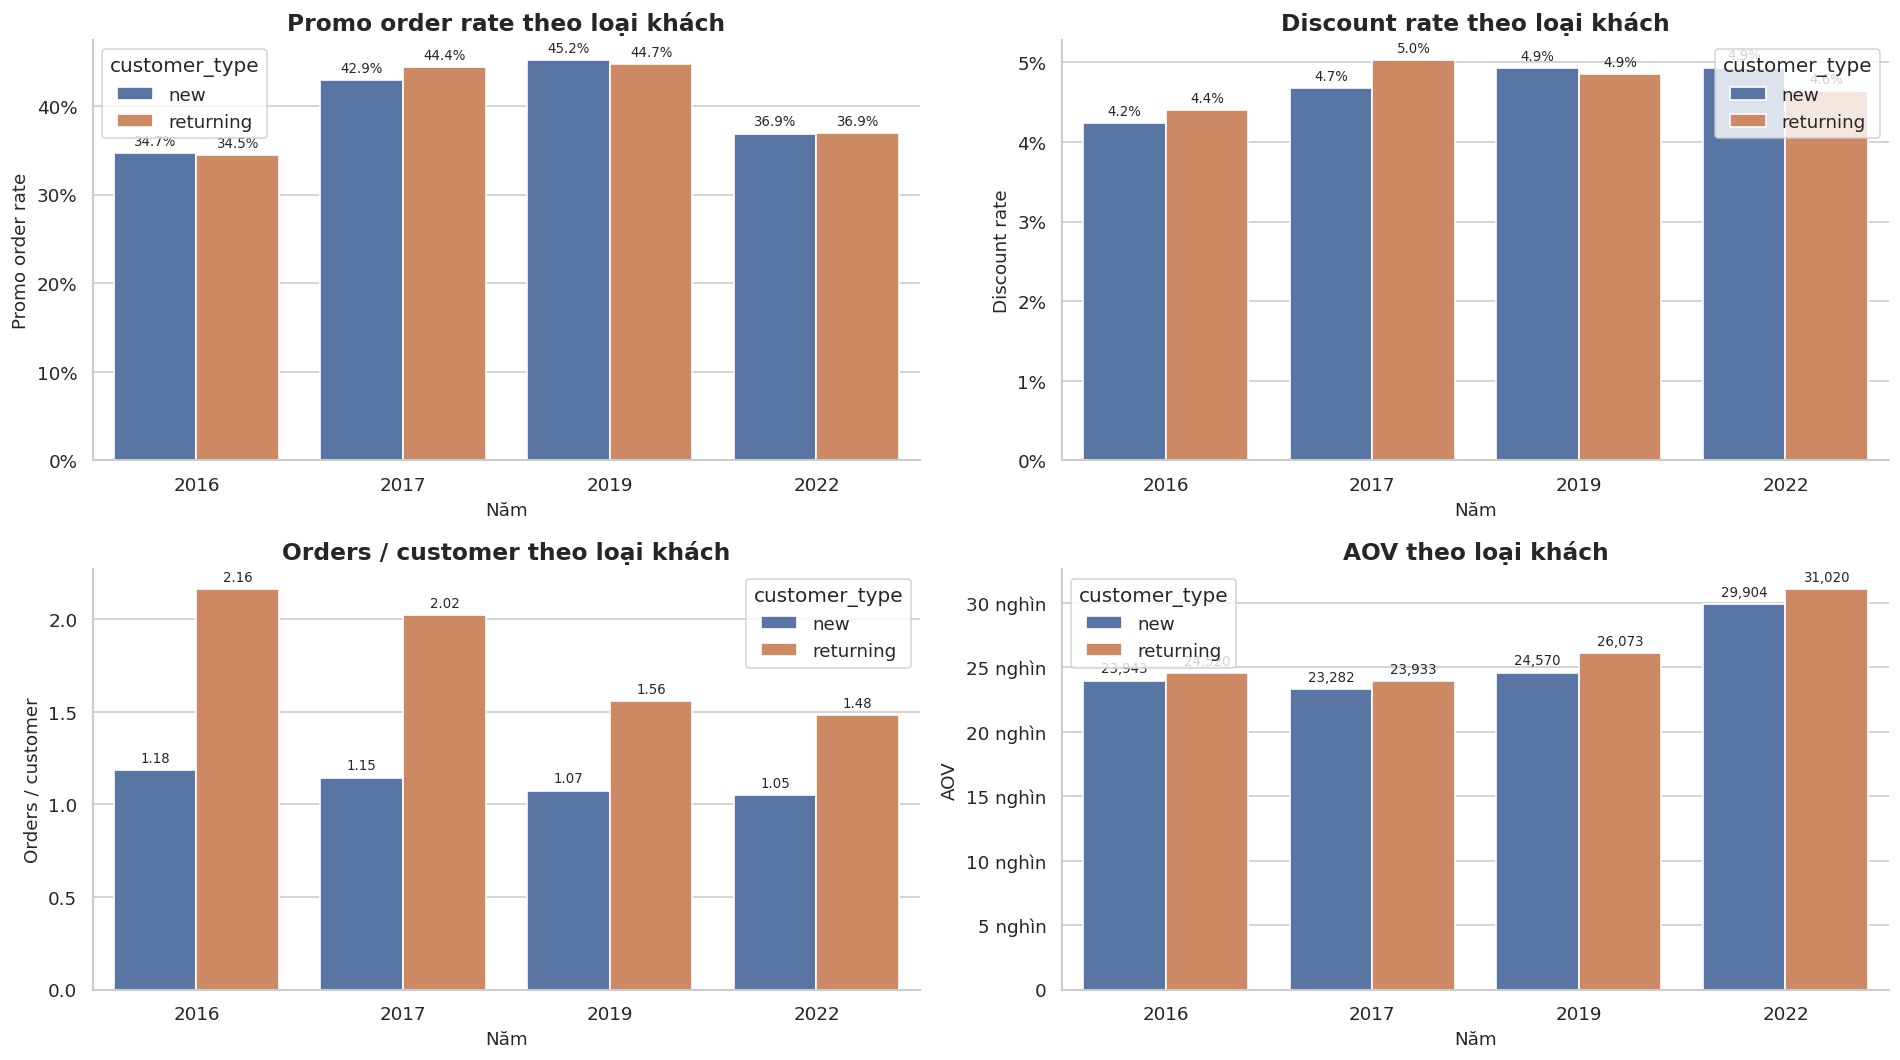

,year,customer_type,customers,orders,net_sales,gross_sales,discount_amount,promo_orders,orders_per_customer,aov,promo_order_rate,discount_rate
7,2016,new,6392,7573,"181,323,575",189347764.210000,8024189.270000,2626,1.18,"23,943",34.68%,4.24%
8,2016,returning,34541,74674,"1,831,040,891",1915292913.330000,84252022.650000,25741,2.16,"24,520",34.47%,4.40%
9,2017,new,4789,5484,"127,677,014",133940537.900000,6263523.830000,2352,1.15,"23,282",42.89%,4.68%
10,2017,returning,34862,70526,"1,687,869,620",1777223787.380000,89354167.470000,31302,2.02,"23,933",44.38%,5.03%
13,2019,new,1898,2039,"50,097,536",52694600.930000,2597064.750000,921,1.07,"24,570",45.17%,4.93%
14,2019,returning,25414,39562,"1,031,492,045",1084106840.580000,52614795.570000,17682,1.56,"26,073",44.69%,4.85%
19,2022,new,1322,1391,"41,595,990",43755798.580000,2159808.440000,513,1.05,"29,904",36.88%,4.94%
20,2022,returning,23374,34613,"1,073,711,106",1125993033.110000,52281926.750000,12772,1.48,"31,020",36.90%,4.64%


**Chú thích dưới mục này - Promo & offer fit:** Promo được đẩy lên ở giai đoạn xấu nhưng không đảo chiều được purchase frequency, đặc biệt với khách quay lại.

- Khách quay lại có `promo_order_rate` tăng từ 34.5% (2016) lên 44.7% (2019), rồi còn 36.9% ở 2022.
- Trong khi đó `orders/customer` của khách quay lại giảm từ 2.16 xuống 1.48.
- `AOV` vẫn tăng từ 24,520 lên 31,020, nên điểm yếu không nằm ở ticket size.
- Hàm ý: Promo đang đóng vai trò chống đỡ ngắn hạn; nếu offer và retention journey không phù hợp thì tăng promo chỉ khó bền vững hơn.

In [8]:
order_fact = order_fact.merge(first_order[["customer_id", "first_order_year"]], on="customer_id", how="left")
order_fact["customer_type"] = np.where(order_fact["year"] == order_fact["first_order_year"], "new", "returning")

promo_type = order_fact.groupby(["year", "customer_type"], as_index=False).agg(
    customers=("customer_id", "nunique"),
    orders=("order_id", "nunique"),
    net_sales=("net_sales", "sum"),
    gross_sales=("gross_sales", "sum"),
    discount_amount=("discount_amount", "sum"),
    promo_orders=("has_promo", "sum"),
)
promo_type["orders_per_customer"] = promo_type["orders"] / promo_type["customers"]
promo_type["aov"] = promo_type["net_sales"] / promo_type["orders"]
promo_type["promo_order_rate"] = promo_type["promo_orders"] / promo_type["orders"]
promo_type["discount_rate"] = promo_type["discount_amount"] / promo_type["gross_sales"]

focus_years = promo_type[promo_type["year"].isin([2016, 2017, 2019, 2022])].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
sns.barplot(data=focus_years, x="year", y="promo_order_rate", hue="customer_type", ax=axes[0, 0])
axes[0, 0].set_title("Promo order rate theo loại khách")
axes[0, 0].set_xlabel("Năm")
axes[0, 0].set_ylabel("Promo order rate")
format_percent_axis(axes[0, 0])
annotate_bar_values(axes[0, 0], as_percent=True)

sns.barplot(data=focus_years, x="year", y="discount_rate", hue="customer_type", ax=axes[0, 1])
axes[0, 1].set_title("Discount rate theo loại khách")
axes[0, 1].set_xlabel("Năm")
axes[0, 1].set_ylabel("Discount rate")
format_percent_axis(axes[0, 1])
annotate_bar_values(axes[0, 1], as_percent=True)

sns.barplot(data=focus_years, x="year", y="orders_per_customer", hue="customer_type", ax=axes[1, 0])
axes[1, 0].set_title("Orders / customer theo loại khách")
axes[1, 0].set_xlabel("Năm")
axes[1, 0].set_ylabel("Orders / customer")
annotate_bar_values(axes[1, 0], as_percent=False, decimals=2)

sns.barplot(data=focus_years, x="year", y="aov", hue="customer_type", ax=axes[1, 1])
axes[1, 1].set_title("AOV theo loại khách")
axes[1, 1].set_xlabel("Năm")
axes[1, 1].set_ylabel("AOV")
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(money_formatter))
annotate_bar_values(axes[1, 1], as_percent=False, decimals=0)
save_figure("02_customer_market_deep_promo", fig)
plt.show()

display(focus_years.style.format({
    "net_sales": "{:,.0f}",
    "orders_per_customer": "{:.2f}",
    "aov": "{:,.0f}",
    "promo_order_rate": "{:.2%}",
    "discount_rate": "{:.2%}",
}))

promo_2016 = focus_years[(focus_years["year"] == 2016) & (focus_years["customer_type"] == "returning")].iloc[0]
promo_2019 = focus_years[(focus_years["year"] == 2019) & (focus_years["customer_type"] == "returning")].iloc[0]
promo_2022 = focus_years[(focus_years["year"] == 2022) & (focus_years["customer_type"] == "returning")].iloc[0]

append_insight(
    section="Promo & offer fit",
    headline="Promo được đẩy lên ở giai đoạn xấu nhưng không đảo chiều được purchase frequency, đặc biệt với khách quay lại.",
    evidence_lines=[
        f"Khách quay lại có `promo_order_rate` tăng từ {promo_2016['promo_order_rate']:.1%} (2016) lên {promo_2019['promo_order_rate']:.1%} (2019), rồi còn {promo_2022['promo_order_rate']:.1%} ở 2022.",
        f"Trong khi đó `orders/customer` của khách quay lại giảm từ {promo_2016['orders_per_customer']:.2f} xuống {promo_2022['orders_per_customer']:.2f}.",
        f"`AOV` vẫn tăng từ {promo_2016['aov']:,.0f} lên {promo_2022['aov']:,.0f}, nên điểm yếu không nằm ở ticket size.",
    ],
    implication="Promo đang đóng vai trò chống đỡ ngắn hạn; nếu offer và retention journey không phù hợp thì tăng promo chỉ khó bền vững hơn.",
    score_updates={"promo_offer_mismatch": 2, "acquisition_retention_break": 1},
)

## 8. Service/ops quality và traffic efficiency: service khá ổn, nhưng conversion từ traffic sang buyer suy giảm mạnh

C:\Users\ACER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ACER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ACER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\ACER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 t

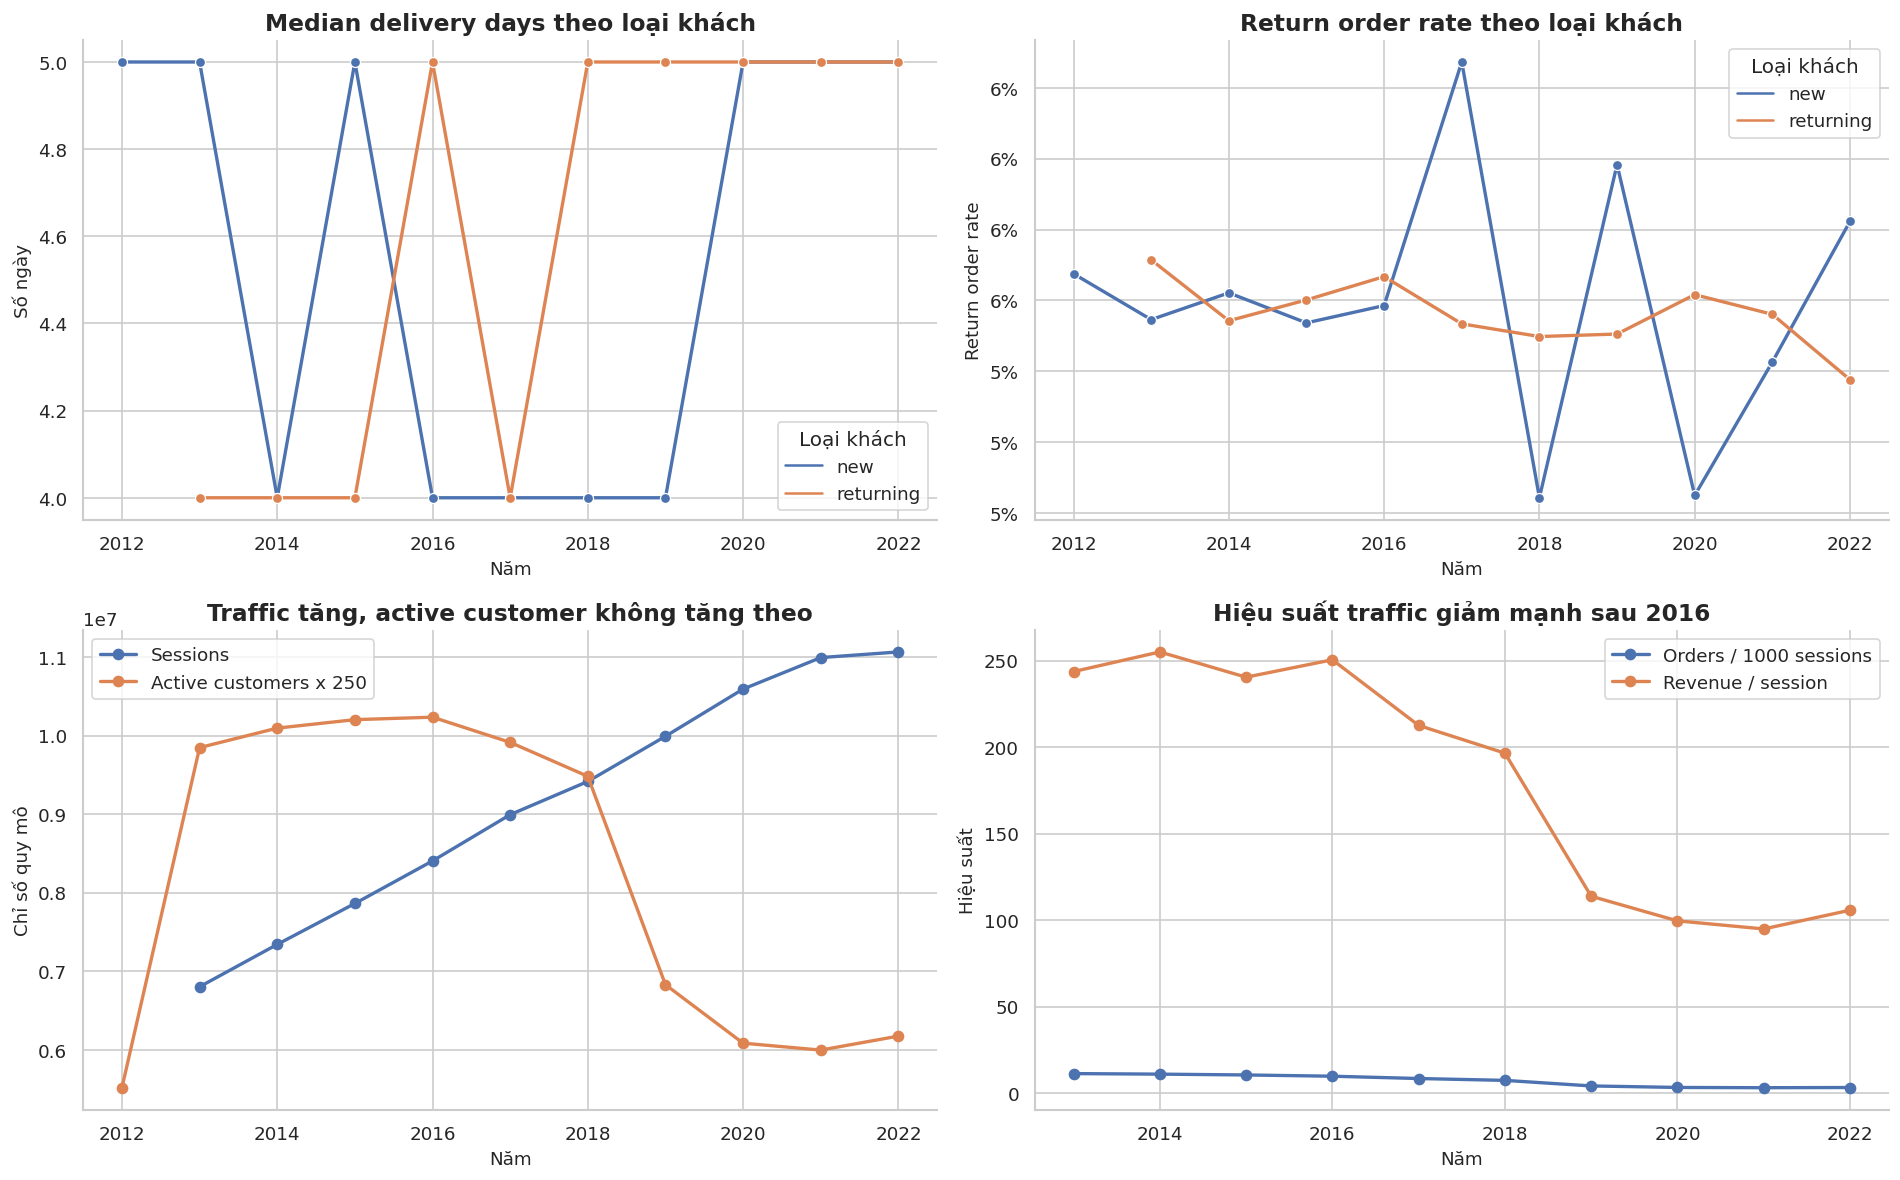

,year,customer_type,orders,return_orders,median_delivery,p90_delivery,avg_shipping_fee,return_order_rate
7,2016,new,7573,423,4.0,7.0,5.02,5.59%
8,2016,returning,74674,4232,5.0,7.0,4.71,5.67%
19,2022,new,1391,81,5.0,7.0,4.33,5.82%
20,2022,returning,34613,1861,5.0,7.0,3.93,5.38%


,year,avg_rating,low_rating_rate
0,2012,3.94,13.32%
1,2013,3.93,13.59%
2,2014,3.93,13.33%
3,2015,3.94,12.80%
4,2016,3.93,13.15%
5,2017,3.94,12.81%
6,2018,3.93,13.29%
7,2019,3.93,13.05%
8,2020,3.98,12.33%
9,2021,3.93,13.26%


,year,active_customers,orders,net_sales,gross_sales,units,orders_per_customer,aov,revenue_per_customer,sessions,unique_visitors,page_views,bounce_rate,duration,Revenue,sessions_per_active_customer,orders_per_1000_sessions,revenue_per_session
1,2013,39384,76849,"1,570,165,169",1657169417.270000,392522,1.951275,20431.823039,39868.097926,"6,801,940",5166501.000000,29403658.000000,0.45%,206.9,"1,657,169,417",172.7,11.30,243.63
2,2014,40376,80645,"1,785,342,715",1871845882.800000,410283,1.997350,22138.293944,44217.919436,"7,340,960",5596248.000000,31947207.000000,0.44%,212.6,"1,871,845,883",181.8,10.99,254.99
3,2015,40807,82622,"1,792,009,967",1889933826.920000,415509,2.024702,21689.259115,43914.278593,"7,861,938",5962192.000000,34175895.000000,0.44%,216.4,"1,889,933,827",192.7,10.51,240.39
4,2016,40933,82247,"2,012,364,466",2104640677.540000,409893,2.009308,24467.329697,49162.398691,"8,403,399",6393654.000000,36322275.000000,0.44%,205.4,"2,104,640,678",205.3,9.79,250.45
5,2017,39651,76010,"1,815,546,634",1911164325.280000,375640,1.916976,23885.628654,45788.167612,"8,992,602",6818372.000000,38785941.000000,0.45%,209.3,"1,911,164,325",226.8,8.45,212.53
6,2018,37922,69510,"1,769,723,180",1850122456.080000,337646,1.832973,25459.979566,46667.453711,"9,415,085",7143496.000000,41461837.000000,0.45%,208.4,"1,850,122,456",248.3,7.38,196.51
7,2019,27312,41601,"1,081,589,581",1136801441.510000,202653,1.523177,25999.124569,39601.258831,"9,990,148",7580565.000000,42927110.000000,0.45%,207.6,"1,136,801,442",365.8,4.16,113.79
8,2020,24335,34881,"1,006,108,536",1054512158.790000,166880,1.433368,28844.027877,41344.094365,"10,591,082",8065367.000000,46146457.000000,0.45%,213.4,"1,054,512,159",435.2,3.29,99.57
9,2021,23984,34525,"991,214,174",1043039819.630000,164743,1.439501,28710.041237,41328.142667,"10,991,725",8367014.000000,47760867.000000,0.45%,210.0,"1,043,039,820",458.3,3.14,94.89
10,2022,24696,36004,"1,115,307,096",1169748831.690000,171088,1.457888,30977.310757,45161.447056,"11,063,658",8409280.000000,47731553.000000,0.45%,212.9,"1,169,748,832",448.0,3.25,105.73


**Chú thích dưới mục này - Service & traffic efficiency:** Service tổng quan khá ổn, nhưng hiệu suất chuyển đổi từ traffic sang buyer giảm rất mạnh.

- Sessions tăng từ 8,403,399 lên 11,063,658.
- Nhưng `orders / 1000 sessions` giảm từ 9.79 xuống 3.25.
- `Revenue / session` giảm từ 250.45 xuống 105.73, trong khi delivery/return không xấu đi tương ứng.
- Hàm ý: Giả thuyết mạnh hơn là conversion, offer fit hoặc CRM journey yếu đi; service breakdown diện rộng không phải lời giải thích chính.

In [9]:
shipments_aug = shipments.merge(
    order_fact[["order_id", "year", "customer_type"]],
    on="order_id",
    how="left",
)
shipments_aug["delivery_days"] = (shipments_aug["delivery_date"] - shipments_aug["ship_date"]).dt.days
service_type = shipments_aug.groupby(["year", "customer_type"], as_index=False).agg(
    median_delivery=("delivery_days", "median"),
    p90_delivery=("delivery_days", lambda s: s.quantile(0.9)),
    avg_shipping_fee=("shipping_fee", "mean"),
)

return_type = (
    returns.merge(order_fact[["order_id", "year", "customer_type"]], on="order_id", how="left")
    .groupby(["year", "customer_type"], as_index=False)
    .agg(return_orders=("order_id", "nunique"))
)
service_base = order_fact.groupby(["year", "customer_type"], as_index=False).agg(
    orders=("order_id", "nunique")
)
service_type = service_base.merge(return_type, on=["year", "customer_type"], how="left").merge(
    service_type, on=["year", "customer_type"], how="left"
)
service_type["return_order_rate"] = service_type["return_orders"] / service_type["orders"]

review_year = reviews.merge(order_fact[["order_id", "year"]], on="order_id", how="left").groupby("year", as_index=False).agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("rating", lambda s: (s <= 2).mean()),
)

traffic_year = (
    web_traffic.assign(year=web_traffic["date"].dt.year)
    .groupby("year", as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        page_views=("page_views", "sum"),
        bounce_rate=("bounce_rate", "mean"),
        duration=("avg_session_duration_sec", "mean"),
    )
)

traffic_eff = annual_customer.merge(traffic_year, on="year", how="left").merge(
    annual_sales[["year", "Revenue"]], on="year", how="left"
)
traffic_eff["sessions_per_active_customer"] = traffic_eff["sessions"] / traffic_eff["active_customers"]
traffic_eff["orders_per_1000_sessions"] = traffic_eff["orders"] / traffic_eff["sessions"] * 1000
traffic_eff["revenue_per_session"] = traffic_eff["Revenue"] / traffic_eff["sessions"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.lineplot(data=service_type, x="year", y="median_delivery", hue="customer_type", marker="o", linewidth=2, ax=axes[0, 0])
axes[0, 0].set_title("Median delivery days theo loại khách")
axes[0, 0].set_xlabel("Năm")
axes[0, 0].set_ylabel("Số ngày")
axes[0, 0].legend(title="Loại khách")

sns.lineplot(data=service_type, x="year", y="return_order_rate", hue="customer_type", marker="o", linewidth=2, ax=axes[0, 1])
axes[0, 1].set_title("Return order rate theo loại khách")
axes[0, 1].set_xlabel("Năm")
axes[0, 1].set_ylabel("Return order rate")
format_percent_axis(axes[0, 1])
axes[0, 1].legend(title="Loại khách")

axes[1, 0].plot(traffic_eff["year"], traffic_eff["sessions"], marker="o", linewidth=2, label="Sessions")
axes[1, 0].plot(traffic_eff["year"], traffic_eff["active_customers"] * 250, marker="o", linewidth=2, label="Active customers x 250")
axes[1, 0].set_title("Traffic tăng, active customer không tăng theo")
axes[1, 0].set_xlabel("Năm")
axes[1, 0].set_ylabel("Chỉ số quy mô")
axes[1, 0].legend()

axes[1, 1].plot(traffic_eff["year"], traffic_eff["orders_per_1000_sessions"], marker="o", linewidth=2, label="Orders / 1000 sessions")
axes[1, 1].plot(traffic_eff["year"], traffic_eff["revenue_per_session"], marker="o", linewidth=2, label="Revenue / session")
axes[1, 1].set_title("Hiệu suất traffic giảm mạnh sau 2016")
axes[1, 1].set_xlabel("Năm")
axes[1, 1].set_ylabel("Hiệu suất")
axes[1, 1].legend()
save_figure("02_customer_market_deep_service_traffic", fig)
plt.show()

traffic_2016 = traffic_eff.loc[traffic_eff["year"] == 2016].iloc[0]
traffic_2022 = traffic_eff.loc[traffic_eff["year"] == 2022].iloc[0]

display(service_type[service_type["year"].isin([2016, 2022])].style.format({
    "median_delivery": "{:.1f}",
    "p90_delivery": "{:.1f}",
    "avg_shipping_fee": "{:.2f}",
    "return_order_rate": "{:.2%}",
}))
display(review_year.style.format({"avg_rating": "{:.2f}", "low_rating_rate": "{:.2%}"}))
display(traffic_eff[traffic_eff["year"] >= 2013].style.format({
    "net_sales": "{:,.0f}",
    "Revenue": "{:,.0f}",
    "sessions": "{:,.0f}",
    "sessions_per_active_customer": "{:,.1f}",
    "orders_per_1000_sessions": "{:.2f}",
    "revenue_per_session": "{:.2f}",
    "bounce_rate": "{:.2%}",
    "duration": "{:.1f}",
}))

append_insight(
    section="Service & traffic efficiency",
    headline="Service tổng quan khá ổn, nhưng hiệu suất chuyển đổi từ traffic sang buyer giảm rất mạnh.",
    evidence_lines=[
        f"Sessions tăng từ {traffic_2016['sessions']:,.0f} lên {traffic_2022['sessions']:,.0f}.",
        f"Nhưng `orders / 1000 sessions` giảm từ {traffic_2016['orders_per_1000_sessions']:.2f} xuống {traffic_2022['orders_per_1000_sessions']:.2f}.",
        f"`Revenue / session` giảm từ {traffic_2016['revenue_per_session']:.2f} xuống {traffic_2022['revenue_per_session']:.2f}, trong khi delivery/return không xấu đi tương ứng.",
    ],
    implication="Giả thuyết mạnh hơn là conversion, offer fit hoặc CRM journey yếu đi; service breakdown diện rộng không phải lời giải thích chính.",
    score_updates={"acquisition_retention_break": 2, "service_breakdown": 0},
)

## 9. Tổng hợp insight cho riêng customer market

In [10]:
score_table = (
    pd.Series(HYPOTHESIS_SCORES, name="score")
    .rename_axis("hypothesis_key")
    .reset_index()
    .assign(hypothesis=lambda d: d["hypothesis_key"].map(HYPOTHESIS_LABELS))
    .sort_values("score", ascending=False)
)
lead_hypothesis = score_table.iloc[0]["hypothesis"]
support_lines = []
for item in INSIGHT_LOG:
    support_lines.append(f"- **{item['section']}**: {item['headline']}")

score_lines = []
for row in score_table.itertuples(index=False):
    score_lines.append(f"- {row.hypothesis}: {row.score} điểm bằng chứng")

if score_table.iloc[0]["hypothesis_key"] == "acquisition_retention_break":
    thesis = (
        "Câu chuyện nhất quán nhất là doanh nghiệp bị gãy ở customer engine: "
        "hút được ít khách mới chất lượng hơn, giữ khách kém hơn và mất dần tầng khách trung thành."
    )
elif score_table.iloc[0]["hypothesis_key"] == "demographic_shift":
    thesis = "Dữ liệu đang nghiêng về giả thuyết mix khách hàng thay đổi là nguyên nhân chính."
elif score_table.iloc[0]["hypothesis_key"] == "promo_offer_mismatch":
    thesis = "Dữ liệu đang nghiêng về giả thuyết promo/offer không còn phù hợp với nhu cầu khách hàng."
else:
    thesis = "Dữ liệu đang nghiêng về giả thuyết service/ops xuống cấp là nguyên nhân chính."

action_lines = [
    "- Ưu tiên phục hồi acquisition efficiency trước khi bơm thêm traffic volume.",
    "- Xây lại retention journey cho cohort mới trong 30-365 ngày sau đơn đầu.",
    "- Bảo vệ và tái kích hoạt tệp khách mua nhiều lần vì đây là lớp doanh thu cấu trúc.",
    "- Dùng promo có chọn lọc, gắn với incremental conversion/lifetime value thay vì chỉ volume ngắn hạn.",
]

summary_lines = [
    "## Tóm tắt customer market insights",
    "",
    f"**Luận điểm chính được dữ liệu ủng hộ mạnh nhất:** {lead_hypothesis}.",
    "",
    thesis,
    "",
    "### Bảng điểm các giả thuyết cạnh tranh",
    "",
    *score_lines,
    "",
    "### Chuỗi bằng chứng xuyên suốt notebook",
    "",
    *support_lines,
    "",
    "### Hàm ý hành động cho phần customer market",
    "",
    *action_lines,
]
summary_block = "\n".join(summary_lines)

display(score_table[["hypothesis", "score"]])
display(Markdown(summary_block))

,hypothesis,score
0,Acquisition và retention bị gãy,13
2,Promo/offer không còn phù hợp,2
1,Chân dung khách hàng dịch chuyển mạnh,0
3,Service/ops xuống cấp,0


## Tóm tắt customer market insights

**Luận điểm chính được dữ liệu ủng hộ mạnh nhất:** Acquisition và retention bị gãy.

Câu chuyện nhất quán nhất là doanh nghiệp bị gãy ở customer engine: hút được ít khách mới chất lượng hơn, giữ khách kém hơn và mất dần tầng khách trung thành.

### Bảng điểm các giả thuyết cạnh tranh

- Acquisition và retention bị gãy: 13 điểm bằng chứng
- Promo/offer không còn phù hợp: 2 điểm bằng chứng
- Chân dung khách hàng dịch chuyển mạnh: 0 điểm bằng chứng
- Service/ops xuống cấp: 0 điểm bằng chứng

### Chuỗi bằng chứng xuyên suốt notebook

- **Dựng fact khách hàng**: Bộ fact đã sẵn sàng để phân rã doanh thu theo hành vi khách hàng thay vì chỉ nhìn tổng doanh thu.
- **Framing doanh thu**: Doanh thu sau đỉnh 2016 suy giảm chủ yếu vì active base và purchase frequency co lại, không phải vì AOV giảm.
- **Chất lượng dữ liệu khách hàng**: `signup_date` không đủ tin cậy để làm acquisition funnel theo thời gian.
- **Acquisition & retention**: Cú giảm doanh thu gắn với sự gãy đồng thời của máy hút khách mới và khả năng giữ khách.
- **Loyalty erosion**: Tệp khách trung thành co lại mạnh, còn tệp mua một lần ngày càng chiếm tỷ trọng lớn hơn.
- **Demographics & market mix**: Mix khách hàng khá ổn định; vấn đề chính là quy mô co lại trên diện rộng chứ không phải dịch chuyển mạnh sang một chân dung mới.
- **Promo & offer fit**: Promo được đẩy lên ở giai đoạn xấu nhưng không đảo chiều được purchase frequency, đặc biệt với khách quay lại.
- **Service & traffic efficiency**: Service tổng quan khá ổn, nhưng hiệu suất chuyển đổi từ traffic sang buyer giảm rất mạnh.

### Hàm ý hành động cho phần customer market

- Ưu tiên phục hồi acquisition efficiency trước khi bơm thêm traffic volume.
- Xây lại retention journey cho cohort mới trong 30-365 ngày sau đơn đầu.
- Bảo vệ và tái kích hoạt tệp khách mua nhiều lần vì đây là lớp doanh thu cấu trúc.
- Dùng promo có chọn lọc, gắn với incremental conversion/lifetime value thay vì chỉ volume ngắn hạn.